# 1. Title Page
**Course Name & Code**: Civil Engineering Methods (Update accordingly)  
**Lab Title**: Linear Algebra Applications – Interpolation  
**Student Name & ID**: Rojyx L. Yangyang 2024p-0118-4 


# 2. Objectives
To apply polynomial interpolation to solve a real-world engineering problem modeling the vertical deflection of a bridge beam. Specifically, this lab utilizes Python and the SymPy library to calculate Newton's Divided Differences, formulate the interpolating polynomial, and extract the quadratic coefficients ($a, b, c$) to estimate beam deflection.

# 3. Problem Statement
A structural engineer is monitoring the vertical deflection of a bridge beam. Sensors placed at three points along the beam record the following deflections:
* Distance x = 0 m, Deflection y = 0 mm (the support)
* Distance x = 10 m, Deflection y = -15 mm
* Distance x = 20 m, Deflection y = 0 mm (the other support)

Task: Use a quadratic polynomial $P(x)=ax^2+bx+c$ to interpolate these points.
1. Solve for the coefficients a, b, and c using Newton's Divided Difference method.
2. Estimate the deflection at the center of the beam (x = 5m).

# 4. Mathematical Formulation
**Newton's Divided Difference Setup:**
For three data points $(x_0, y_0), (x_1, y_1), (x_2, y_2)$, a quadratic Newton interpolating polynomial takes the form:
$$f_2(x) = b_0 + b_1(x-x_0) + b_2(x-x_0)(x-x_1)$$

The divided difference coefficients are evaluated as follows:
* **0th Order**: $b_0 = f(x_0)$
* **1st Order**: $b_1 = \frac{f(x_1) - f(x_0)}{x_1 - x_0}$
* **2nd Order**: $b_2 = \frac{f[x_1, x_2] - f[x_0, x_1]}{x_2 - x_0}$ where $f[x_1, x_2] = \frac{f(x_2) - f(x_1)}{x_2 - x_1}$

Once $f_2(x)$ is formulated, expanding the mathematical expression yields the standard polynomial $P(x) = ax^2 + bx + c$. By comparing terms, the coefficients $a, b,$ and $c$ are directly extracted from the expanded Newton polynomial.

--- 1. NEWTON'S DIVIDED DIFFERENCE CALCULATIONS ---
Calculated Divided Differences: b0 = 0, b1 = -1.5, b2 = 0.15
Newton's Unexpanded Form: P(x) = 0.15*x*(x - 10) - 1.5*x

--- 2. EXTRACTING COEFFICIENTS (a, b, c) ---
Expanded Quadratic Polynomial: P(x) = 0.15*x**2 - 3.0*x
Extracted Variables:
a = 0.150000000000000
b = -3.00000000000000
c = 0

--- 3. ESTIMATION ---
Estimated beam deflection at x = 5m is: -11.2500000000000 mm



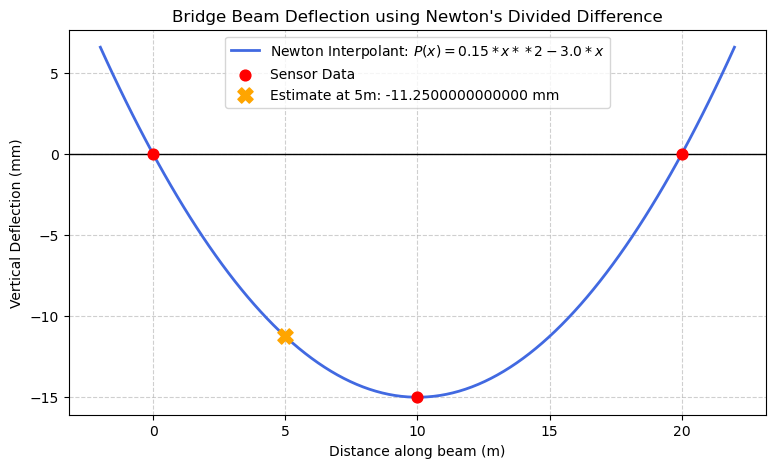

In [3]:
# 5. Python Implementation (Code)
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Define the symbol
x = sp.Symbol('x')

# Sensor data points
x_data = [0, 10, 20]
y_data = [0, -15, 0]

print("--- 1. NEWTON'S DIVIDED DIFFERENCE CALCULATIONS ---")
# Step 1: Calculate the divided differences
b0 = y_data[0]
b1 = (y_data[1] - y_data[0]) / (x_data[1] - x_data[0])

# Intermediate 1st-order difference between point 2 and 1
f_x1_x2 = (y_data[2] - y_data[1]) / (x_data[2] - x_data[1])

# 2nd-order difference
b2 = (f_x1_x2 - b1) / (x_data[2] - x_data[0])

print(f"Calculated Divided Differences: b0 = {b0}, b1 = {b1}, b2 = {b2}")

# Step 2: Formulate Newton's Polynomial
newton_poly = b0 + b1*(x - x_data[0]) + b2*(x - x_data[0])*(x - x_data[1])
print(f"Newton's Unexpanded Form: P(x) = {newton_poly}")

print("\n--- 2. EXTRACTING COEFFICIENTS (a, b, c) ---")
# Step 3: Expand the polynomial to get ax^2 + bx + c form
expanded_poly = sp.expand(newton_poly)
print(f"Expanded Quadratic Polynomial: P(x) = {expanded_poly}")

# Step 4: Extract a, b, and c using SymPy's coeff method
a_val = expanded_poly.coeff(x, 2)
b_val = expanded_poly.coeff(x, 1)
c_val = expanded_poly.subs(x, 0) # Substitute x=0 to get the constant term

print(f"Extracted Variables:")
print(f"a = {a_val}")
print(f"b = {b_val}")
print(f"c = {c_val}")

print("\n--- 3. ESTIMATION ---")
# Estimate deflection at x = 5m
x_target = 5
deflection_at_5 = expanded_poly.subs(x, x_target)
print(f"Estimated beam deflection at x = {x_target}m is: {deflection_at_5} mm\n")

# 6. Results & Data Visualization
# Convert SymPy expression to a NumPy function for smooth plotting
P_func = sp.lambdify(x, expanded_poly, 'numpy')

# Generate curve data
x_vals = np.linspace(-2, 22, 100)
y_vals = P_func(x_vals)

# Plotting the results
plt.figure(figsize=(9, 5))
plt.plot(x_vals, y_vals, label=f'Newton Interpolant: $P(x) = {expanded_poly}$', color='royalblue', linewidth=2)
plt.scatter(x_data, y_data, color='red', zorder=5, s=60, label='Sensor Data')
plt.scatter(x_target, deflection_at_5, color='orange', zorder=5, marker='X', s=120, label=f'Estimate at 5m: {deflection_at_5} mm')

# Graph aesthetics
plt.title('Bridge Beam Deflection using Newton\'s Divided Difference')
plt.xlabel('Distance along beam (m)')
plt.ylabel('Vertical Deflection (mm)')
plt.axhline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# 6. Results
Using Newton's Divided Difference method, the divided difference coefficients were calculated as $b_0 = 0.0$, $b_1 = -1.5$, and $b_2 = 0.15$. 
Substituting these into Newton's formula yielded $P(x) = 0 - 1.5(x) + 0.15(x)(x-10)$.

By expanding this formula using SymPy, the required variables for the standard quadratic polynomial $P(x) = ax^2 + bx + c$ were successfully extracted:
* $a = 0.15$
* $b = -3.0$
* $c = 0.0$

The final interpolating polynomial modeling the deflection is: **$P(x) = 0.15x^2 - 3.0x$**.
Applying $x = 5$ meters to this polynomial estimates the beam's deflection to be **-11.25 mm**.

# 7. Discussion & Conclusion
* **Interpretation of Results:** Newton's Divided Difference method successfully formulated a continuous quadratic model for the beam's profile. The calculated deflection at 5m (-11.25 mm) correctly falls on the curve between the zero-deflection support and the maximum deflection at 10m (-15mm), validating the physical intuition of a sagging bridge beam. Extracting $a, b,$ and $c$ through polynomial expansion proves that Newton's method is highly effective not just for interpolation, but also for identifying governing equation variables.
* **Limitations of the Model:** Polynomial interpolation mathematically forces the curve through the given points, but bridges do not always follow perfect quadratic curves (they are often modeled with cubic or higher-order splines). Furthermore, polynomials can become highly inaccurate if used to extrapolate outside the given sensor domain (e.g., $x < 0$ or $x > 20$).